In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Setup Graph Style
plt.style.use('seaborn-v0_8-whitegrid')
print("✅ Libraries Loaded")

✅ Libraries Loaded


In [2]:
# Cell 2: Load Data
print("Loading Full Dataset...")
df = pd.read_csv('data/final_training_data.csv')

# Features and Labels
X = df.drop(columns=['Label']).values
y = df['Label'].values

# Scale (Crucial for SVM and KNN)
# We train a FRESH scaler for these models to be self-contained
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split (80% Train, 20% Test) - Same as Deep Learning
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} samples")
print(f"Testing on {len(X_test)} samples")

Loading Full Dataset...
Training on 24441 samples
Testing on 6111 samples


In [3]:
# Cell 3: Training Session
# Dictionary of models to train
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1), # n_jobs=-1 uses all CPU cores
    "SVM (RBF Kernel)": SVC(kernel='rbf', probability=True), # probability=True allows confidence scores
    "KNN (5 Neighbors)": KNeighborsClassifier(n_neighbors=5)
}

trained_models = {}
results = []

print("🚀 Starting Training (This may take 2-5 minutes)...")

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    
    # Evaluate
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    
    print(f"   ✅ {name} Accuracy: {acc*100:.2f}%")
    
    # Save results
    trained_models[name] = model
    results.append({'Model': name, 'Accuracy': acc})
    
    # Save the model file (in case we want to use it later)
    filename = f"models/{name.replace(' ', '_').lower()}.pkl"
    joblib.dump(model, filename)

print("🏁 All models trained and saved.")

🚀 Starting Training (This may take 2-5 minutes)...
Training Logistic Regression...
   ✅ Logistic Regression Accuracy: 87.27%
Training Random Forest...
   ✅ Random Forest Accuracy: 98.76%
Training SVM (RBF Kernel)...
   ✅ SVM (RBF Kernel) Accuracy: 89.63%
Training KNN (5 Neighbors)...
   ✅ KNN (5 Neighbors) Accuracy: 98.38%
🏁 All models trained and saved.


/var/folders/m7/bxrchhk523j23yqt7zxk659c0000gn/T/ipykernel_7308/193797799.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Accuracy', y='Model', data=res_df, palette='viridis')


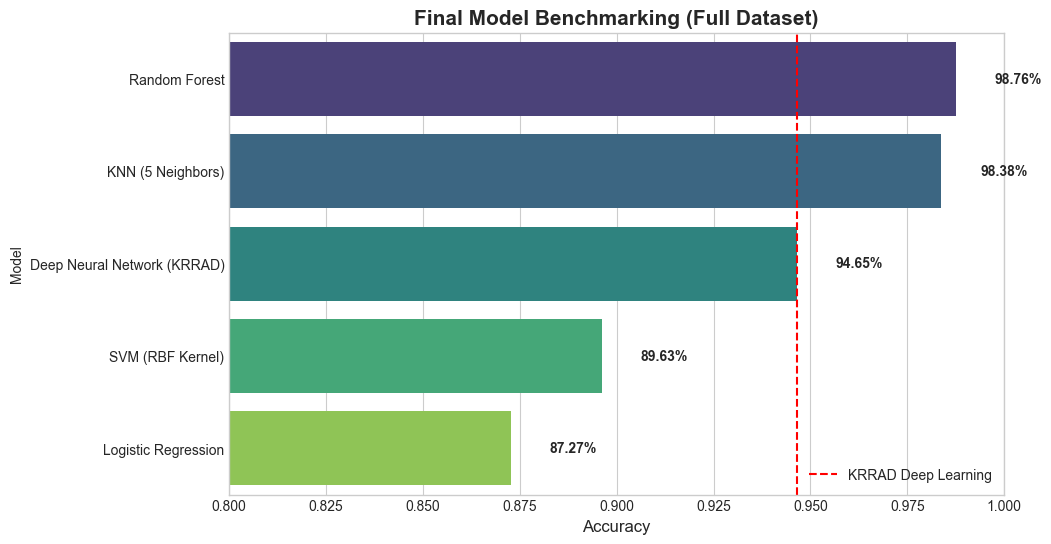

In [4]:
# Cell 4: Visualization
# --- MANUALLY ENTER YOUR DEEP LEARNING SCORE HERE ---
dl_acc = 0.9465  # From your last screenshot
# ----------------------------------------------------

# Add DL to results
results.append({'Model': 'Deep Neural Network (KRRAD)', 'Accuracy': dl_acc})

# Create DataFrame
res_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='Accuracy', y='Model', data=res_df, palette='viridis')

# Add text labels on bars
for i, p in enumerate(barplot.patches):
    width = p.get_width()
    plt.text(width + 0.01, p.get_y() + p.get_height()/2, 
             f'{width*100:.2f}%', va='center', fontweight='bold')

plt.title('Final Model Benchmarking (Full Dataset)', fontsize=15, fontweight='bold')
plt.xlabel('Accuracy', fontsize=12)
plt.xlim(0.8, 1.0) # Zoom in on the top performers
plt.axvline(dl_acc, color='red', linestyle='--', label='KRRAD Deep Learning')
plt.legend()
plt.show()